# Лабораторная работа №1. 

**Цель:** демонстрация способности нейронной сети решать задачи классификации. Сеть необходимо обучить классификации по 2 классам. Необходимо реализовать модель на любом языке программирования без использования специализированных библиотек для реализации нейронных сетей.


**Выполнила:** студентка группы 6231-090401D Ризванова Э.Т.

**Задание 20:**
Используемая модель – гипер радиально-базисная сеть.

### 1. Параметры нейронной сети

In [2]:
import math
import random
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

RANDOM_SEED = 42
LEARNING_RATE = 0.01
TRAIN_SPLIT = 0.8
HIDDEN_NEURONS = 32
EPOCHS = 50

random.seed(RANDOM_SEED)

### 2. Работа с данными

#### Загрузка данных:

In [3]:
def load_iris_binary():
    data = load_iris()
    X = data.data
    y = data.target
    binary_data = []
    feature_names = data.feature_names

    for features, label in zip(X, y):
        if label != 0:
            label = 0 if label == 1 else 1
            binary_data.append((list(map(float, features)), label))
    return binary_data, feature_names

#### Диаграмма рассеивания:

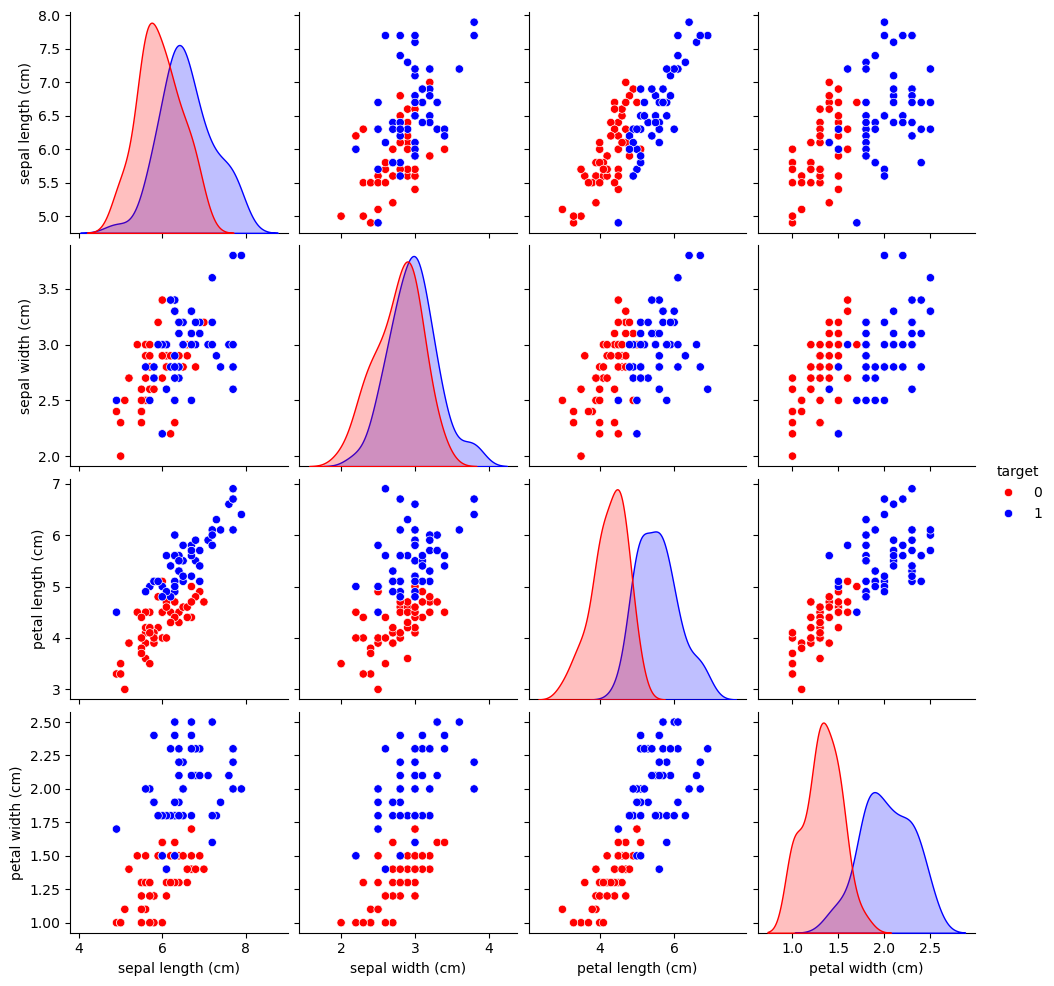

In [4]:
def plot_scatter():
    data, feature_names = load_iris_binary()
    X = [d[0] for d in data]
    y = [d[1] for d in data]

    df = pd.DataFrame(X, columns=feature_names)
    df["target"] = y

    sns.pairplot(df, hue='target', palette={0: 'red', 1: 'blue'}, vars=feature_names)
    plt.show()

plot_scatter()

#### Минимаксная нормализация:

In [5]:
def normalize_features(data):
    n_features = len(data[0][0])
    x_i = [[] for _ in range(n_features)]

    for x, _ in data:
        for i, value in enumerate(x):
            x_i[i].append(value)

    x_mins = [min(value) for value in x_i]
    x_maxs = [max(value) for value in x_i]
    normed = []

    for x, y in data:
        normed_x = []
        for i, value in enumerate(x):
            rng = x_maxs[i] - x_mins[i]
            normed_x.append(0 if rng == 0 else (value - x_mins[i]) / rng)
        normed.append((normed_x, y))
    return normed

#### Деление на обучающую и тестовую выборку:

In [6]:
def stratified_split(data, train_ratio):
    class0 = [d for d in data if d[1] == 0]
    class1 = [d for d in data if d[1] == 1]

    n0 = int(len(class0) * train_ratio)
    n1 = int(len(class1) * train_ratio)

    train = class0[:n0] + class1[:n1]
    test = class0[n0:] + class1[n1:]

    random.shuffle(train)
    random.shuffle(test)
    return train, test

### 3. Модель нейронной сети

#### Расчет центров:

In [7]:
def compute_class_centers(data):
    class0 = [d[0] for d in data if d[1] == 0]
    class1 = [d[0] for d in data if d[1] == 1]

    def mean_vec(xs):
        n = len(xs)
        m = len(xs[0])
        return [sum(xs[k][j] for k in range(n)) / n for j in range(m)]

    c0 = mean_vec(class0)
    c1 = mean_vec(class1)
    return [c0, c1]

#### HRBF-сеть с диагональной Q:

In [8]:
class HRBF:
    def __init__(self, n_features, n_hidden, class_centers):
        self.n_inputs = n_features
        self.n_hidden = n_hidden
        self.centers = []

        for i in range(n_hidden):
            c = class_centers[i % 2]
            noisy = [c[j] + random.uniform(-0.01, 0.01) for j in range(self.n_inputs)]
            self.centers.append(noisy)

        self.Q = [1.0 for _ in range(self.n_inputs)]
        self.W = [random.uniform(-0.05, 0.05) for _ in range(self.n_hidden)]
        self.W0 =  1

    def compute_phi(self, x, i):
        z = [self.Q[j] * (x[j] - self.centers[i][j]) for j in range(self.n_inputs)]
        u = sum(zj ** 2 for zj in z)
        phi = math.exp(-0.5 * u)
        return z, phi

    def compute_y(self, x):
        zs, phis = [], []
        for i in range(self.n_hidden):
            z, phi = self.compute_phi(x, i)
            zs.append(z)
            phis.append(phi)

        y_raw = self.W0 + sum(self.W[i] * phis[i] for i in range(self.n_hidden))
        y_class = 0 if y_raw < 0.5 else 1
        return y_raw, y_class, phis, zs

    def train_single(self, x, d, lr):
        y_raw, _, phis, zs = self.compute_y(x)
        err = y_raw - d
        self.W0 -= lr * err

        for i in range(self.n_hidden):
            w_i = self.W[i]
            grad_w = phis[i] * err
            self.W[i] -= lr * grad_w

            for j in range(self.n_inputs):
                diff = x[j] - self.centers[i][j]
                qj = self.Q[j]

                common = - phis[i] * w_i * err
                grad_c = common * qj * zs[i][j]
                grad_q = common * diff * zs[i][j]

                self.Q[j] -= lr * grad_q
                self.centers[i][j] -= lr * grad_c

    def train(self, train_data, epochs, lr, verbose=False):
        for epoch in range(1, epochs + 1):
            random.shuffle(train_data)
            for x, d in train_data:
                self.train_single(x, d, lr)

            if verbose and (epoch == 1 or epoch % 10 == 0 or epoch == epochs):
                acc, mse, _ = self.evaluate(train_data)
                print(f"Epoch {epoch}/{epochs}  accuracy={acc:.4f}  error={(1 - acc):.4f}  MSE={mse:.4f}")

        acc, mse, _ = self.evaluate(train_data)
        return acc, mse

    def predict(self, x):
        y_pred, y_class, _, _ = self.compute_y(x)
        return y_pred, y_class

    def evaluate(self, data, verbose=False):
        idx = mse = TP = TN = FP = FN = 0
        for x, d in data:
            y_raw, y_pred = self.predict(x)
            mse += (y_raw - d) ** 2
            if d == 1:
                if y_pred == 1:
                    TP += 1
                else:
                    FN += 1
            else:
                if y_pred == 1:
                    FP += 1
                else:
                    TN += 1

            if verbose and idx < 10:
                if idx == 0:
                    print("Пример предсказания классов (первые 10):")
                print(f"{idx:2} actual={d} pred={y_pred} raw={y_raw:.4f}")
                idx += 1

        acc = (TP + TN) / len(data)
        mse /= len(data)
        return acc, mse, {"TP":TP,"FN":FN,"FP":FP,"TN":TN}

### 4. Обучение и тестирование сети

In [9]:
def test():
    binary_data, feature_names = load_iris_binary()
    normed_data = normalize_features(binary_data)
    print(f"Количество образцов: {len(normed_data)}, Признаки: {feature_names}")

    train_data, test_data = stratified_split(normed_data, TRAIN_SPLIT)
    c0_train = sum(1 for d in train_data if d[1] == 0)
    c1_train = sum(1 for d in train_data if d[1] == 1)
    print(f"Обучающая выборка: 0={c0_train}  1={c1_train} ({len(train_data)})")

    c0_test = sum(1 for d in test_data if d[1] == 0)
    c1_test = sum(1 for d in test_data if d[1] == 1)
    print(f"Тестовая выборка:  0={c0_test}  1={c1_test} ({len(test_data)})")

    n_features = len(train_data[0][0])
    class_centers = compute_class_centers(train_data)
    model = HRBF(n_features, HIDDEN_NEURONS, class_centers)

    print("\nПараметры сети:")
    print(f"  Коэффициент обучения: {LEARNING_RATE}")
    print(f"  Объём обучающей выборки: {TRAIN_SPLIT}")
    print(f"  Число нейронов: {HIDDEN_NEURONS}")
    print(f"  Число эпох: {EPOCHS}")

    print("\nОбучение сети...")
    train_acc, train_mse = model.train(train_data, EPOCHS, LEARNING_RATE, True)
    print(f"Обучение завершено. accuracy: {train_acc:.4f}, error: {(1 - train_acc):.4f}, MSE: {train_mse:.4f}")

    print("\nТестирование сети...")
    test_acc, test_mse, cm = model.evaluate(test_data, True)
    print(f"Тестирование завершено. accuracy: {test_acc:.4f}, error: {(1 - test_acc):.4f}, MSE: {test_mse:.4f}")
    
    cm_matrix = [
        [cm["TP"], cm["FN"]],
        [cm["FP"], cm["TN"]]
    ]

    plt.figure()
    sns.heatmap(cm_matrix, annot=True, cmap="Greens")
    plt.xlabel("Предсказанные классы")
    plt.ylabel("Истинные классы")
    plt.title("Матрица ошибок")
    plt.show()
    return normed_data

Количество образцов: 100, Признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Обучающая выборка: 0=40  1=40 (80)
Тестовая выборка:  0=10  1=10 (20)

Параметры сети:
  Коэффициент обучения: 0.01
  Объём обучающей выборки: 0.8
  Число нейронов: 32
  Число эпох: 50

Обучение сети...
Epoch 1/50  accuracy=0.7250  error=0.2750  MSE=0.1928
Epoch 10/50  accuracy=0.8125  error=0.1875  MSE=0.1447
Epoch 20/50  accuracy=0.9250  error=0.0750  MSE=0.0835
Epoch 30/50  accuracy=0.9000  error=0.1000  MSE=0.0903
Epoch 40/50  accuracy=0.9000  error=0.1000  MSE=0.0822
Epoch 50/50  accuracy=0.9000  error=0.1000  MSE=0.0867
Обучение завершено. accuracy: 0.9000, error: 0.1000, MSE: 0.0867

Тестирование сети...
Пример предсказания классов (первые 10):
 0 actual=1 pred=1 raw=0.5281
 1 actual=0 pred=0 raw=-0.0574
 2 actual=0 pred=0 raw=0.0927
 3 actual=1 pred=1 raw=0.9784
 4 actual=0 pred=0 raw=-0.1031
 5 actual=1 pred=1 raw=0.9523
 6 actual=0 pred=0 raw=-0.0396
 7 actua

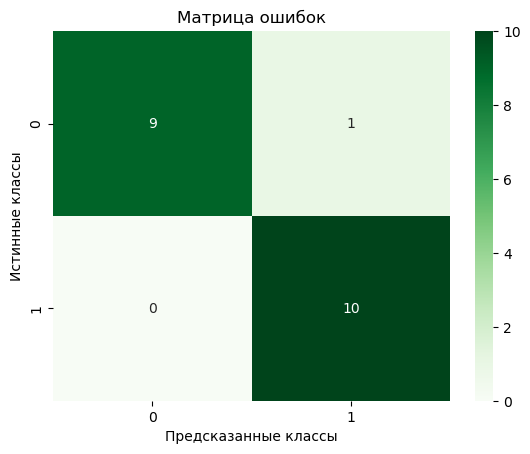

In [10]:
normed_data = test()

### 5. Исследование зависимости погрешности обучения от значения коэффициента обучения

In [11]:
train_data, test_data = stratified_split(normed_data, TRAIN_SPLIT)

In [12]:
def run_experiment(learning_rate, hidden_neurons, epochs, train_set, test_set):
    class_centers = compute_class_centers(train_set)
    n_features = len(train_set[0][0])

    net = HRBF(n_features, hidden_neurons, class_centers)
    _, train_mse = net.train(train_set, epochs, learning_rate)

    test_acc, _, _ = net.evaluate(test_set)
    test_err = 1 - test_acc
    return train_mse, test_err

In [13]:
def experiment_learning_rate(rates):
    train_errors = []
    for lr in rates:
        err, _ = run_experiment(lr, HIDDEN_NEURONS, EPOCHS, train_data, test_data)
        train_errors.append(err)

    min_err = min(train_errors)
    index = train_errors.index(min_err)
    best_rates = rates[index]
    print(f"Наименьшая погрешность: {min_err:.4f}, learning_rate={best_rates}")

    plt.figure()
    plt.plot(rates, train_errors, marker="o")
    plt.xlabel("Коэффициент обучения")
    plt.ylabel("Погрешность")
    plt.title("Зависимость погрешности обучения от коэффициента обучения")
    plt.ylim(bottom=0)
    plt.xscale('linear')
    plt.grid()
    plt.show()
    return best_rates

Наименьшая погрешность: 0.0658, learning_rate=0.023


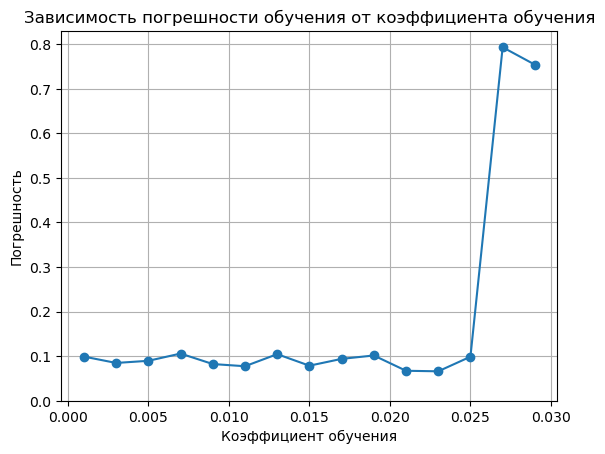

In [14]:
rates = [0.001 + i * 0.002 for i in range(15)]
LEARNING_RATE = experiment_learning_rate(rates)

### 6. Исследование зависимости погрешности обучения от объёма обучающей выборки

In [15]:
def experiment_train_size(splits):
    train_errors = []
    for split in splits:
        train_set, test_set = stratified_split(normed_data, split)
        err, _ = run_experiment(LEARNING_RATE, HIDDEN_NEURONS, EPOCHS, train_set, test_set)
        train_errors.append(err)

    min_err = min(train_errors)
    index = train_errors.index(min_err)
    best_split = splits[index]
    print(f"Наименьшая погрешность: {min_err:.4f}, splits={best_split}")

    plt.figure()
    plt.plot(splits, train_errors, marker="o")
    plt.xlabel("Объём обучающей выборки")
    plt.ylabel("Погрешность")
    plt.title("Зависимость погрешности обучения от объёма обучающей выборки")
    plt.ylim(bottom=0)
    plt.xscale('linear')
    plt.grid()
    plt.show()
    return best_split

Наименьшая погрешность: 0.0697, splits=0.75


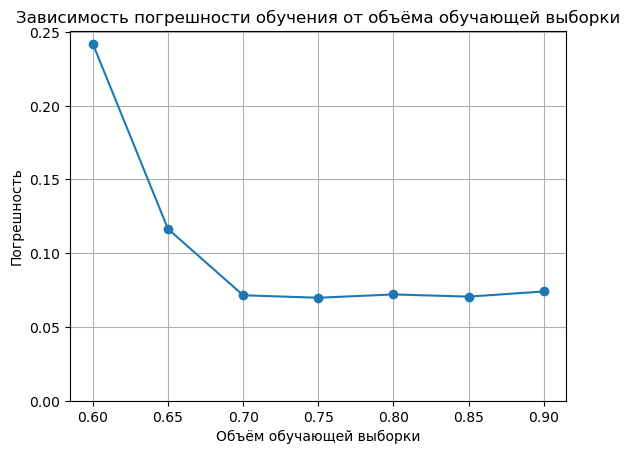

In [16]:
splits = [0.6 + i * 0.05 for i in range(7)]
TRAIN_SPLIT = experiment_train_size(splits)
train_data, test_data = stratified_split(normed_data, TRAIN_SPLIT)

### 7. Исследование зависимости погрешности классификации от числа нейронов скрытого слоя

In [17]:
def experiment_hidden_neurons(neurons):
    test_errors = []
    for n in neurons:
        _, err = run_experiment(LEARNING_RATE, n, EPOCHS, train_data, test_data)
        test_errors.append(err)

    min_err = min(test_errors)
    index = test_errors.index(min_err)
    best_neurons = neurons[index]
    print(f"Наименьшая погрешность: {min_err:.4f}, neurons={best_neurons}")

    plt.figure()
    plt.plot(neurons, test_errors, marker="o")
    plt.xlabel("Число нейронов")
    plt.ylabel("Погрешность")
    plt.title("Зависимость погрешности классификации от числа нейронов скрытого слоя")
    plt.ylim(bottom=0)
    plt.xscale('linear')
    plt.grid()
    plt.show()
    return best_neurons

Наименьшая погрешность: 0.0000, neurons=32


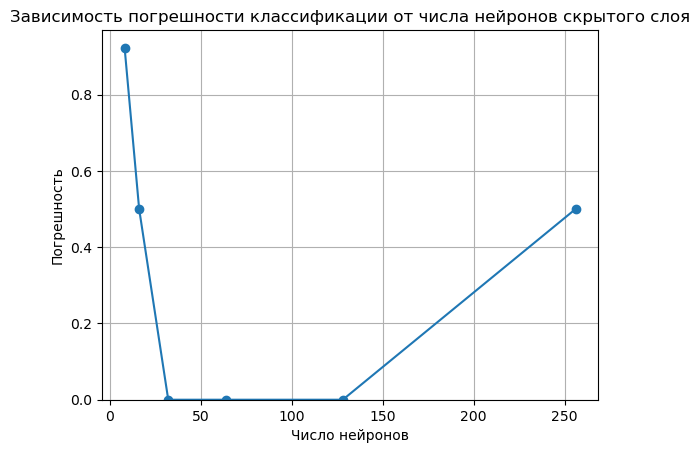

In [18]:
HIDDEN_NEURONS = experiment_hidden_neurons([8, 16, 32, 64, 128, 256])

### 8. Исследование зависимости погрешности классификации от числа эпох обучения

In [19]:
def experiment_epochs(epochs):
    test_errors = []
    for ep in epochs:
        _, err = run_experiment(LEARNING_RATE, HIDDEN_NEURONS, ep, train_data, test_data)
        test_errors.append(err)

    min_err = min(test_errors)
    index = test_errors.index(min_err)
    best_epochs = epochs[index]
    print(f"Наименьшая погрешность: {min_err:.4f}, epochs={epochs[index]}")

    plt.figure()
    plt.plot(epochs, test_errors, marker="o")
    plt.xlabel("Число эпох обучения")
    plt.ylabel("Погрешность")
    plt.title("Зависимость погрешности классификации от числа эпох обучения")
    plt.ylim(bottom=0)
    plt.xscale('linear')
    plt.grid()
    plt.show()
    return best_epochs

Наименьшая погрешность: 0.0000, epochs=10


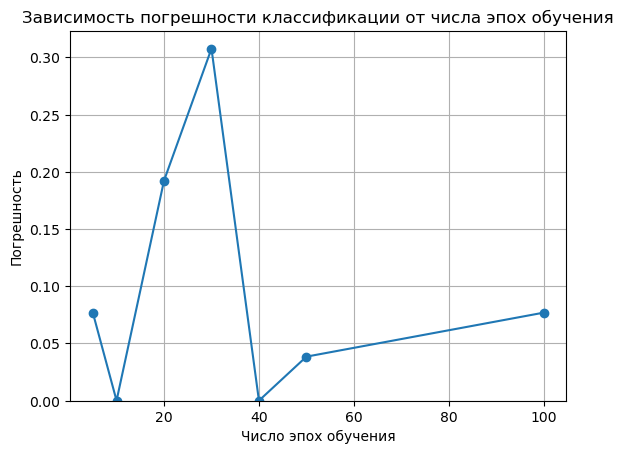

In [20]:
EPOCHS = experiment_epochs([5, 10, 20, 30, 40, 50, 100])

### Оптимальные параметры сети:

Количество образцов: 100, Признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Обучающая выборка: 0=37  1=37 (74)
Тестовая выборка:  0=13  1=13 (26)

Параметры сети:
  Коэффициент обучения: 0.023
  Объём обучающей выборки: 0.75
  Число нейронов: 32
  Число эпох: 40

Обучение сети...
Epoch 1/40  accuracy=0.7568  error=0.2432  MSE=0.1701
Epoch 10/40  accuracy=0.7973  error=0.2027  MSE=0.1276
Epoch 20/40  accuracy=0.8108  error=0.1892  MSE=0.1209
Epoch 30/40  accuracy=0.9054  error=0.0946  MSE=0.0791
Epoch 40/40  accuracy=0.8649  error=0.1351  MSE=0.1002
Обучение завершено. accuracy: 0.8649, error: 0.1351, MSE: 0.1002

Тестирование сети...
Пример предсказания классов (первые 10):
 0 actual=0 pred=0 raw=0.1529
 1 actual=0 pred=0 raw=0.1242
 2 actual=0 pred=0 raw=0.1237
 3 actual=0 pred=0 raw=0.2236
 4 actual=0 pred=0 raw=0.1405
 5 actual=0 pred=0 raw=0.1873
 6 actual=0 pred=0 raw=0.3271
 7 actual=1 pred=1 raw=0.8524
 8 actual=1 pred=1 raw=0.7313
 9 a

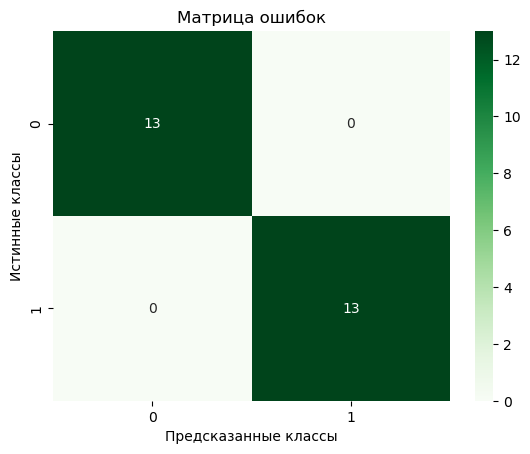

[([0.6999999999999998,
   0.6666666666666669,
   0.4358974358974359,
   0.2666666666666666],
  0),
 ([0.5, 0.6666666666666669, 0.3846153846153846, 0.3333333333333333], 0),
 ([0.6666666666666666,
   0.6111111111111113,
   0.4871794871794872,
   0.3333333333333333],
  0),
 ([0.19999999999999987,
   0.16666666666666657,
   0.2564102564102564,
   0.20000000000000004],
  0),
 ([0.5333333333333332,
   0.44444444444444436,
   0.41025641025641013,
   0.3333333333333333],
  0),
 ([0.2666666666666666,
   0.44444444444444436,
   0.3846153846153846,
   0.20000000000000004],
  0),
 ([0.4666666666666665,
   0.7222222222222222,
   0.4358974358974359,
   0.4000000000000001],
  0),
 ([0.0, 0.22222222222222218, 0.07692307692307687, 0.0], 0),
 ([0.5666666666666664, 0.5, 0.41025641025641013, 0.20000000000000004], 0),
 ([0.09999999999999994,
   0.388888888888889,
   0.23076923076923073,
   0.2666666666666666],
  0),
 ([0.033333333333333215, 0.0, 0.1282051282051282, 0.0], 0),
 ([0.3333333333333333,
   0.555

In [21]:
EPOCHS = 40
test()